In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

size_m2 = np.random.uniform(50, 250, 200)
price = 3000 * size_m2 + np.random.normal(0, 50000, 200) + 20000

df = pd.DataFrame({"size_m2": size_m2, "price": price})
df.head()

,size_m2,price
0,124.908024,360722.835229
1,240.142861,752041.268704
2,196.398788,623849.988752
3,169.731697,493477.519617
4,81.203728,356899.909823


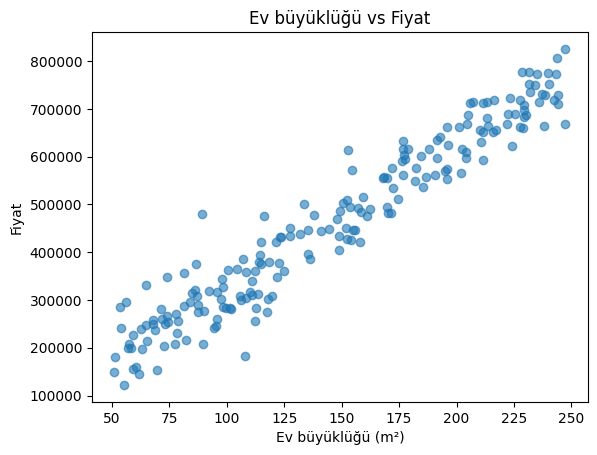

<Figure size 640x480 with 0 Axes>

In [6]:
plt.scatter(df["size_m2"], df["price"], alpha=0.6)
plt.xlabel("Ev büyüklüğü (m²)")
plt.ylabel("Fiyat")
plt.title("Ev büyüklüğü vs Fiyat")
plt.show()
plt.savefig("../results/lstm_vs_gru_predictions.png", dpi=150, bbox_inches="tight")

In [3]:
X = df[["size_m2"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Katsayı (eğim):", model.coef_[0])
print("Kesişim:", model.intercept_)

Katsayı (eğim): 3026.1758951069587
Kesişim: 19418.067966429924


In [4]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MSE: 2,711,559,656.36
RMSE: 52,072.64


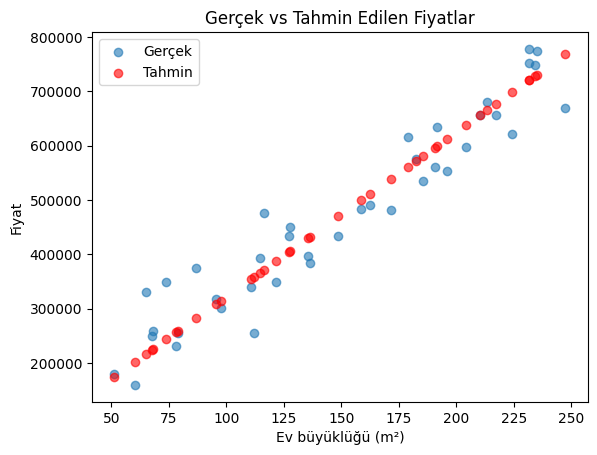

In [5]:
plt.scatter(X_test, y_test, alpha=0.6, label="Gerçek")
plt.scatter(X_test, y_pred, alpha=0.6, label="Tahmin", color="red")
plt.xlabel("Ev büyüklüğü (m²)")
plt.ylabel("Fiyat")
plt.legend()
plt.title("Gerçek vs Tahmin Edilen Fiyatlar")
plt.show()